# Building a Perceptual Map with Multidimensional Scaling (MDS)

## Scenario
A product team wants to understand how similar or different its subscription bundles
appear based on their feature attributes. You will derive a dissimilarity matrix from
bundle characteristics and use MDS to create a 2D perceptual map, then interpret
the map to identify positioning opportunities.

## Your task
You will produce:
1. A dissimilarity matrix **D** (bundle × bundle) derived from standardized attributes
2. A labeled 2D MDS perceptual map
3. Identification of the **closest substitute pair** (smallest off-diagonal distance)
4. Identification of the **whitespace opportunity** (most differentiated bundle)
5. A 2–4 sentence written interpretation with positioning implications

## Requirements
- Use `candidate_bundles.csv`
- Engineer features: `log_storage`, `is_priority`, `is_noads`, `is_offline`
  plus `price_usd` and `family_seats`
- Standardize all features before computing distances
- Run `MDS(n_components=2, dissimilarity="precomputed", random_state=42)`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [3]:
# ── Step 1: Load data and inspect ────────────────────────────────────────
df = pd.read_csv(BUNDLES_PATH)
df

,bundle,price_usd,storage_gb,support,ads,family_seats,offline_download
0,Budget,5,50,Standard,Ads,1,No
1,Mid,8,200,Standard,NoAds,4,Yes
2,Premium,15,1000,Priority,NoAds,6,Yes
3,ValuePlus,12,200,Priority,NoAds,4,Yes


In [4]:
# ── Step 2: Engineer numeric features ────────────────────────────────────
# Log-transform storage to reduce skew; binary flags for categorical attributes
df = df.copy()
df['log_storage']  = np.log(df['storage_gb'])
df['is_priority']  = (df['support']          == 'Priority').astype(int)
df['is_noads']     = (df['ads']              == 'NoAds').astype(int)
df['is_offline']   = (df['offline_download'] == 'Yes').astype(int)

feat_cols = ['price_usd','log_storage','family_seats','is_priority','is_noads','is_offline']
X_raw = df[feat_cols].astype(float).values
print("Feature matrix shape:", X_raw.shape)

Feature matrix shape: (4, 6)


In [5]:
# ── Step 3: Standardize features ─────────────────────────────────────────
# Standardize so all features contribute equally to Euclidean distance
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

In [6]:
# ── Step 4: Compute the dissimilarity matrix D ───────────────────────────
# Euclidean distance on standardized features = dissimilarity between bundles
n = len(X)
D = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        D[i, j] = np.sqrt(np.sum((X[i] - X[j]) ** 2))

bundle_names = df['bundle'].tolist()
df_D = pd.DataFrame(D, index=bundle_names, columns=bundle_names)
df_D.round(3)

,Budget,Mid,Premium,ValuePlus
Budget,0.000,3.977,6.114,4.752
Mid,3.977,0.000,3.307,2.259
Premium,6.114,3.307,0.000,2.044
ValuePlus,4.752,2.259,2.044,0.000


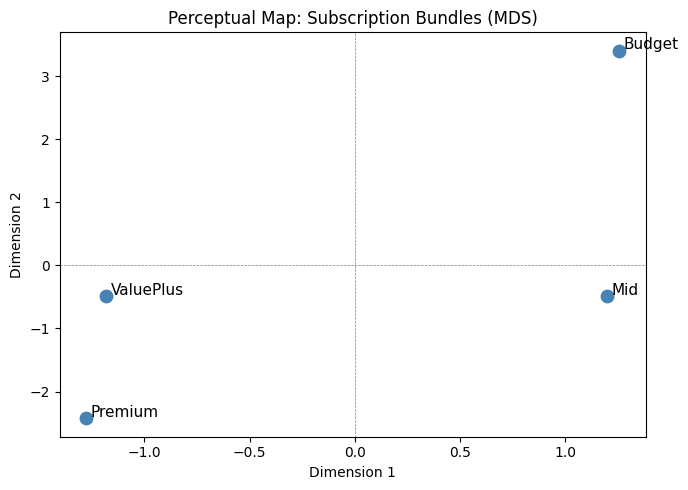

In [7]:
# ── Step 5: Run MDS and plot the perceptual map ──────────────────────────
# MDS finds a 2D layout that preserves pairwise distances as closely as possible
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(D)

df_mds = pd.DataFrame({'bundle': bundle_names, 'x': coords[:, 0], 'y': coords[:, 1]})

plt.figure(figsize=(7, 5))
plt.scatter(df_mds['x'], df_mds['y'], s=80, color='steelblue')
for _, row in df_mds.iterrows():
    plt.annotate(row['bundle'], (row['x'] + 0.02, row['y'] + 0.02), fontsize=11)
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Perceptual Map: Subscription Bundles (MDS)")
plt.tight_layout()
plt.show()

In [8]:
# ── Step 6: Identify closest substitutes and whitespace ──────────────────
# Closest substitute pair: smallest non-zero distance
pairs = [(bundle_names[i], bundle_names[j], float(D[i, j]))
         for i in range(n) for j in range(i + 1, n)]
closest = sorted(pairs, key=lambda t: t[2])[0]
print(f"Closest substitute pair: {closest[0]} vs {closest[1]}  (distance = {closest[2]:.3f})")

# Whitespace bundle: most differentiated (highest average distance to others)
avg_dist = df_D.replace(0.0, np.nan).mean(axis=1).sort_values(ascending=False)
whitespace_bundle = avg_dist.index[0]
print(f"Whitespace bundle (most distinct): {whitespace_bundle}  (avg distance = {avg_dist.iloc[0]:.3f})")

Closest substitute pair: Premium vs ValuePlus  (distance = 2.044)
Whitespace bundle (most distinct): Budget  (avg distance = 4.948)


## Positioning Interpretation

In the markdown cell below, write **2–4 sentences** addressing:
1. What does the closest substitute pair tell you about **cannibalization risk**?
2. What positioning opportunity does the whitespace bundle represent?
3. Based on the map, how would you differentiate the new tier's messaging?

In [9]:
# Print summary to guide interpretation
closest_a, closest_b, closest_d = closest
print(f"Interpretation:")
print(f"  {closest_a} and {closest_b} share very similar feature profiles (distance={closest_d:.3f}).")
print(f"  Positioning them with the same messaging risks cannibalization — one should be")
print(f"  differentiated on a key attribute (e.g., price tier or a flagship feature).")
print()
print(f"  {whitespace_bundle} is the most distinct bundle (avg distance={avg_dist.iloc[0]:.3f}).")
print(f"  It occupies whitespace in the perceptual map and has the strongest differentiation")
print(f"  opportunity — messaging should emphasize what makes it uniquely valuable.")

Interpretation:
  Premium and ValuePlus share very similar feature profiles (distance=2.044).
  Positioning them with the same messaging risks cannibalization — one should be
  differentiated on a key attribute (e.g., price tier or a flagship feature).

  Budget is the most distinct bundle (avg distance=4.948).
  It occupies whitespace in the perceptual map and has the strongest differentiation
  opportunity — messaging should emphasize what makes it uniquely valuable.
